# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

> **안내** : "## 5. 다음 단계 안내"까지는 과제에서 제공된 scratch 노트북(Batch 1 로딩·기초 EDA)이다. 정리 전 데이터 기준이므로 숫자가 보고서·README(정리 후 기준)와 다를 수 있다. 직접 수행한 분석은 "## 배치 비교 (Batch 1 · 2 · 3)"부터다.

In [1]:
# !pip install mat73 h5py

In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# 데이터 경로 설정
DATA_DIR = "../data/archive"

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : ../data/archive
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [4]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [8]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [9]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [10]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [11]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [12]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

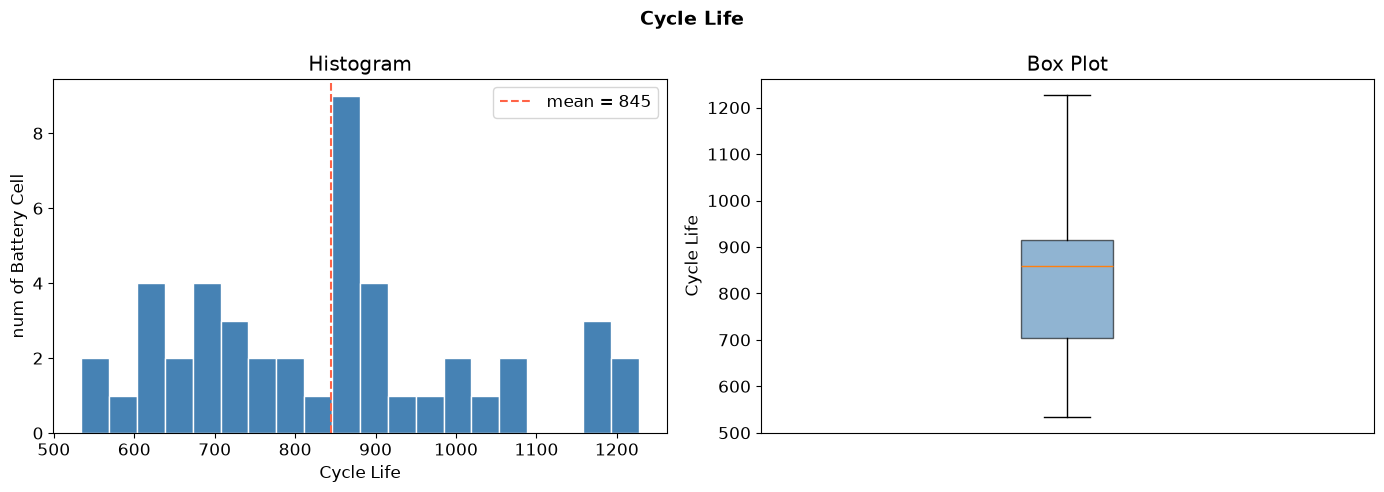

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [13]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

In [19]:
# Q1. 장수명 / 단수명 개수 세기
cl = cycle_life_df["cycle_life"]

print(f"전체 배터리       : {len(cl)}개")
print(f"장수명 (1,000 초과): {(cl > 1000).sum()}개 ({(cl > 1000).mean()*100:.1f}%)")
print(f"단수명 (500 미만)  : {(cl < 500).sum()}개 ({(cl < 500).mean()*100:.1f}%)")
print(f"550 미만           : {(cl < 550).sum()}개  ← 분류 문제의 '단수명' 기준")

print("\n[가장 짧은 배터리 5개]")
print(cycle_life_df.sort_values("cycle_life").head(5))

전체 배터리       : 46개
장수명 (1,000 초과): 10개 (21.7%)
단수명 (500 미만)  : 0개 (0.0%)
550 미만           : 1개  ← 분류 문제의 '단수명' 기준

[가장 짧은 배터리 5개]
       cell_id  cycle_life charging_policy
18782       20         534  5.4C(80%)-5.4C
19315       21         559  5.4C(80%)-5.4C
38213       45         599    8C(35%)-3.6C
37598       44         616    8C(35%)-3.6C
32992       38         617    7C(40%)-3.6C


### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

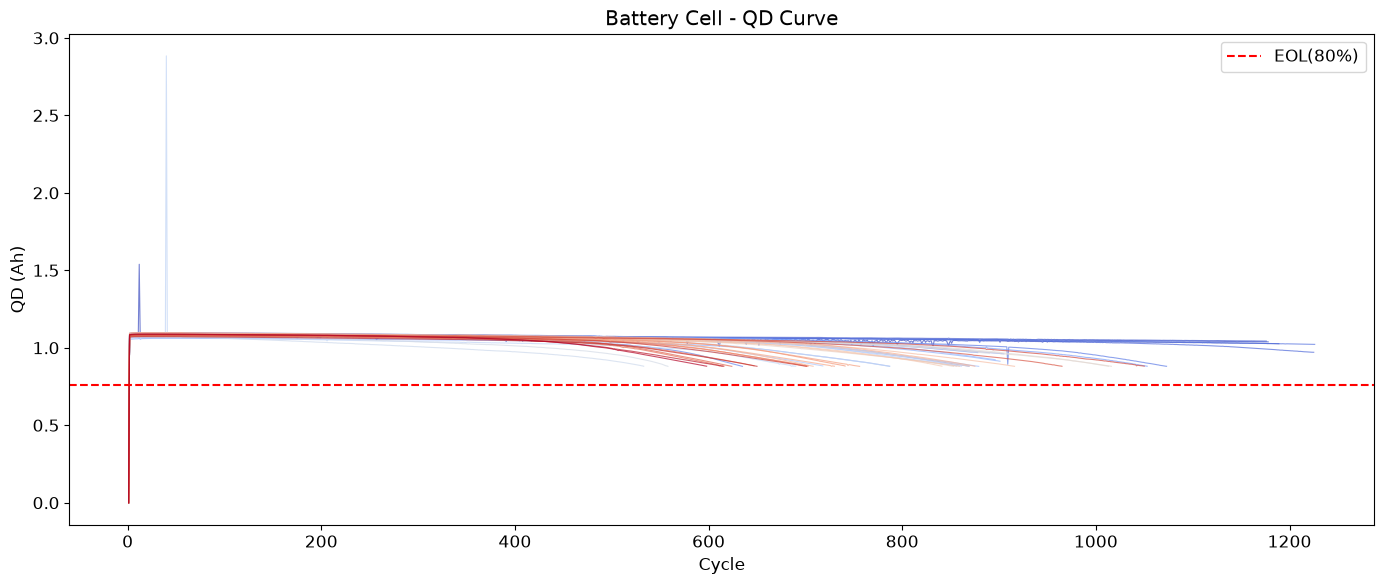

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


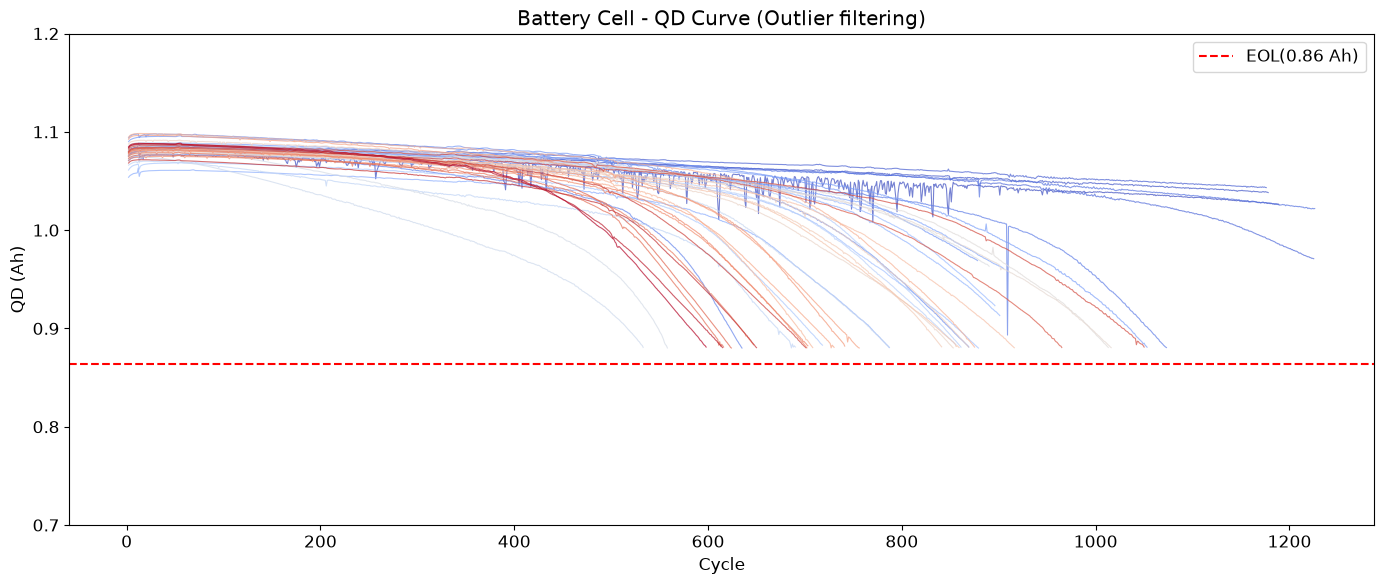

In [15]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

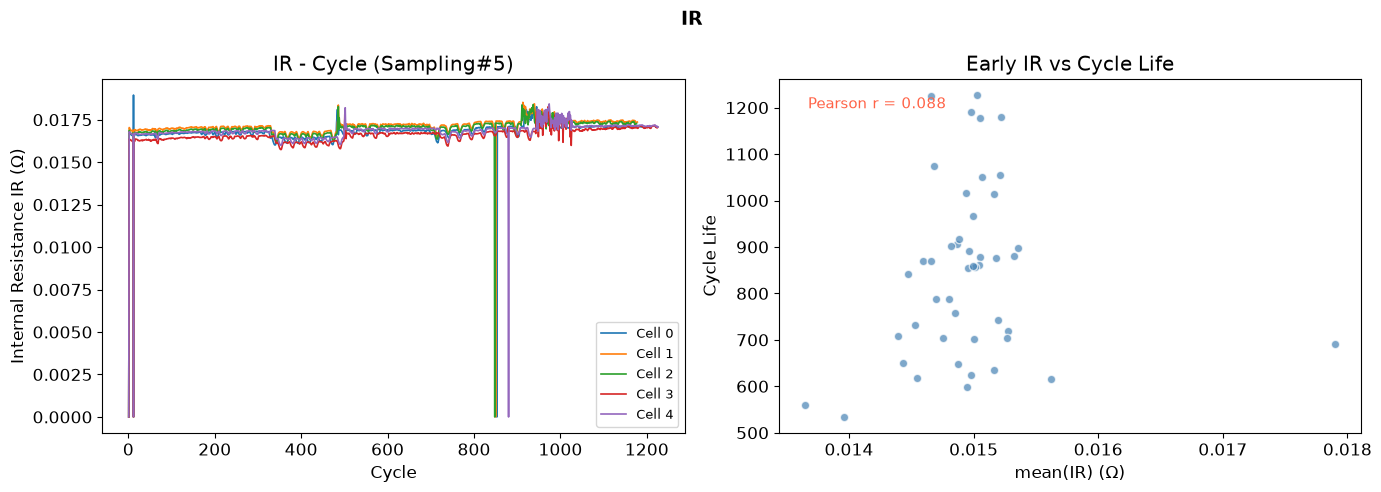

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

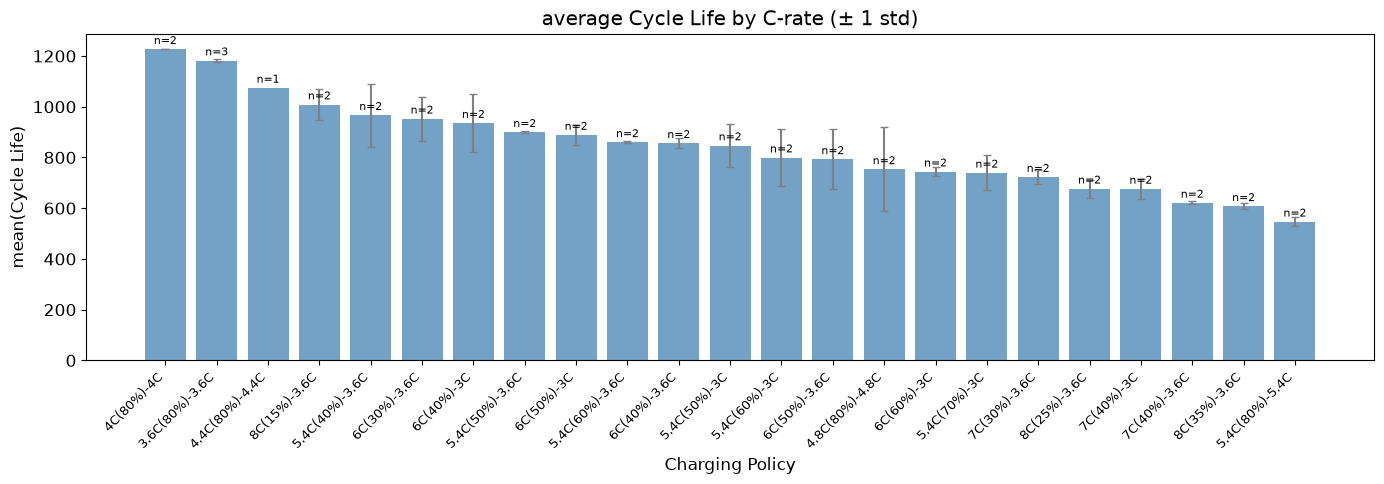

In [17]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

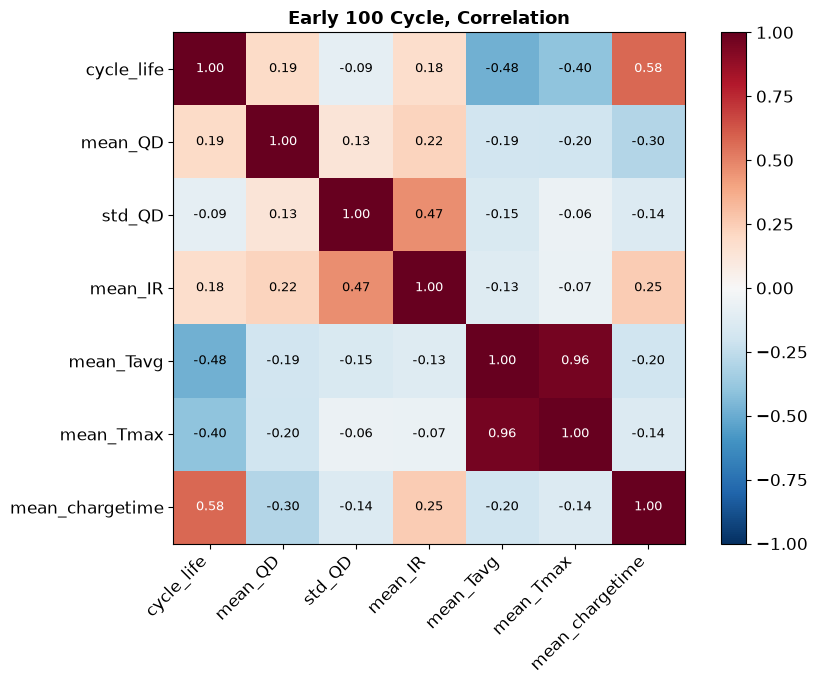


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [18]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

> **정정** : 위 해석의 "인과관계 확인"은 상관관계만으로는 말할 수 없다. 온도와 수명은 음의 상관이 있고, 도메인상 발열이 열화를 가속할 수 있다는 근거와 일치한다는 수준으로 해석한다. (아래 Q4·Q5 분석 참고)

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

## 배치 비교 (Batch 1 · 2 · 3)

In [20]:
# Batch 1 원본이 메모리를 많이 차지하므로 먼저 비움
import gc

for v in ["mat", "batch", "cycles", "cycles_raw", "cell0"]:
    if v in globals():
        del globals()[v]
gc.collect()
print("메모리 정리 완료")

메모리 정리 완료


In [21]:
BATCH_FILES = {
    "Batch1": "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch2": "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch3": "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
N_KEEP = 101  # Qdlin은 사이클 0~100번만 보관 (질문 3 ΔQ(V) 계산용)


def load_batch(name, fname):
    """배치 파일 1개 → (배터리 표, 사이클 표, 초기 Qdlin) 추출 후 원본 메모리 해제"""
    mat = load_mat(os.path.join(DATA_DIR, fname))
    cells = to_list_of_dicts(mat["batch"])

    cell_rows, summary_parts, qdlin = [], [], {}
    for i, cell in enumerate(cells):
        key = f"{name}_{i}"
        cl = cell["cycle_life"]
        cl = float(np.asarray(cl).squeeze()) if cl is not None else np.nan
        policy = str(cell.get("policy_readable") or cell.get("policy") or "unknown")
        cell_rows.append(
            {
                "batch": name,
                "cell_key": key,
                "cell_id": i,
                "cycle_life": cl,
                "charging_policy": policy,
            }
        )

        s = cell["summary"]
        n = len(s["QDischarge"])
        part = pd.DataFrame(
            {
                "cycle": np.arange(1, n + 1),
                "QD": s["QDischarge"],
                "QC": s["QCharge"],
                "IR": s["IR"],
                "Tmax": s["Tmax"],
                "Tavg": s["Tavg"],
                "Tmin": s["Tmin"],
                "chargetime": s["chargetime"],
            }
        )
        part.insert(0, "cell_key", key)
        part.insert(0, "batch", name)
        summary_parts.append(part)

        cyc = cell["cycles"]
        qdlin[key] = (
            list(cyc["Qdlin"][:N_KEEP])
            if isinstance(cyc, dict)
            else [c["Qdlin"] for c in cyc[:N_KEEP]]
        )

    del mat, cells
    gc.collect()
    return pd.DataFrame(cell_rows), pd.concat(summary_parts, ignore_index=True), qdlin


cells_list, summary_list, qdlin_all = [], [], {}
for name, fname in BATCH_FILES.items():
    print(f"\n===== {name} 로딩 중 =====")
    c, s, q = load_batch(name, fname)
    cells_list.append(c)
    summary_list.append(s)
    qdlin_all.update(q)
    print(f"→ {name} : 배터리 {len(c)}개, 사이클 기록 {len(s):,}줄")

cells_df = pd.concat(cells_list, ignore_index=True)
summary_df = pd.concat(summary_list, ignore_index=True)

# 다음에 다시 안 읽어도 되도록 저장 (data/ 폴더라 GitHub에는 안 올라감)
import pickle

cells_df.to_pickle("../data/cells_df.pkl")
summary_df.to_pickle("../data/summary_df.pkl")
with open("../data/qdlin_early.pkl", "wb") as f:
    pickle.dump(qdlin_all, f)
print("\n저장 완료")


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro


===== Batch1 로딩 중 =====
로드 완료 (MATLAB v7.3 / HDF5 형식)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

→ Batch1 : 배터리 46개, 사이클 기록 38,811줄

===== Batch2 로딩 중 =====
로드 완료 (MATLAB v7.3 / HDF5 형식)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

→ Batch2 : 배터리 47개, 사이클 기록 26,904줄

===== Batch3 로딩 중 =====
로드 완료 (MATLAB v7.3 / HDF5 형식)
→ Batch3 : 배터리 46개, 사이클 기록 51,007줄

저장 완료


In [22]:
g = cells_df.groupby("batch")["cycle_life"]
q1_compare = pd.DataFrame(
    {
        "배터리 수": g.size(),
        "수명 기록 없음": g.apply(lambda x: x.isna().sum()),
        "평균": g.mean().round(1),
        "중앙값": g.median(),
        "표준편차": g.std().round(1),
        "최소": g.min(),
        "최대": g.max(),
        "장수명(>1000)": g.apply(lambda x: (x > 1000).sum()),
        "550 미만": g.apply(lambda x: (x < 550).sum()),
    }
)
q1_compare

,배터리 수,수명 기록 없음,평균,중앙값,표준편차,최소,최대,장수명(>1000),550 미만
batch,,,,,,,,,
Batch1,46,0,844.7,858.5,184.6,534.0,1227.0,10,1
Batch2,47,8,565.7,472.0,222.2,392.0,1186.0,3,30
Batch3,46,2,1059.7,1005.5,313.9,541.0,1935.0,23,1


## Q2. 열화 곡선

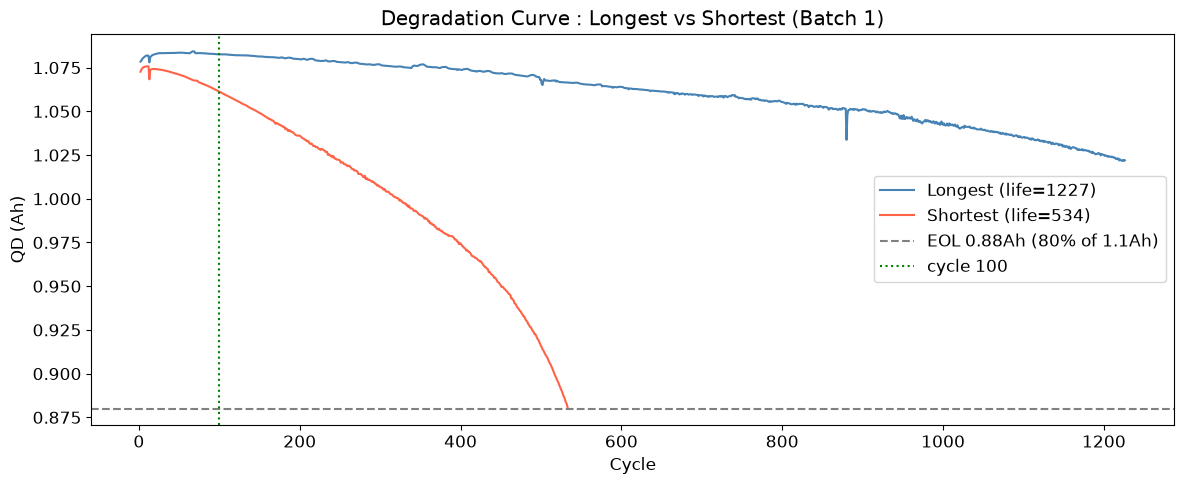

In [23]:
# Q2-1. 가장 긴 수명 vs 가장 짧은 수명 배터리 (Batch 1)
cells_df = pd.read_pickle("../data/cells_df.pkl")
summary_df = pd.read_pickle("../data/summary_df.pkl")

valid = cells_df.dropna(subset=["cycle_life"])  # 수명(정답) 없는 셀 제외
b1 = valid[valid["batch"] == "Batch1"]
long_key = b1.loc[b1["cycle_life"].idxmax(), "cell_key"]
short_key = b1.loc[b1["cycle_life"].idxmin(), "cell_key"]

fig, ax = plt.subplots(figsize=(12, 5))
for key, color, name in [
    (long_key, "steelblue", "Longest"),
    (short_key, "tomato", "Shortest"),
]:
    sub = summary_df[
        (summary_df["cell_key"] == key) & (summary_df["QD"].between(0.7, 1.2))
    ]
    life = int(b1.loc[b1["cell_key"] == key, "cycle_life"].iloc[0])
    ax.plot(sub["cycle"], sub["QD"], color=color, label=f"{name} (life={life})")

ax.axhline(0.88, color="gray", linestyle="--", label="EOL 0.88Ah (80% of 1.1Ah)")
ax.axvline(100, color="green", linestyle=":", label="cycle 100")
ax.set_xlabel("Cycle")
ax.set_ylabel("QD (Ah)")
ax.set_title("Degradation Curve : Longest vs Shortest (Batch 1)")
ax.legend()
plt.tight_layout()
plt.show()

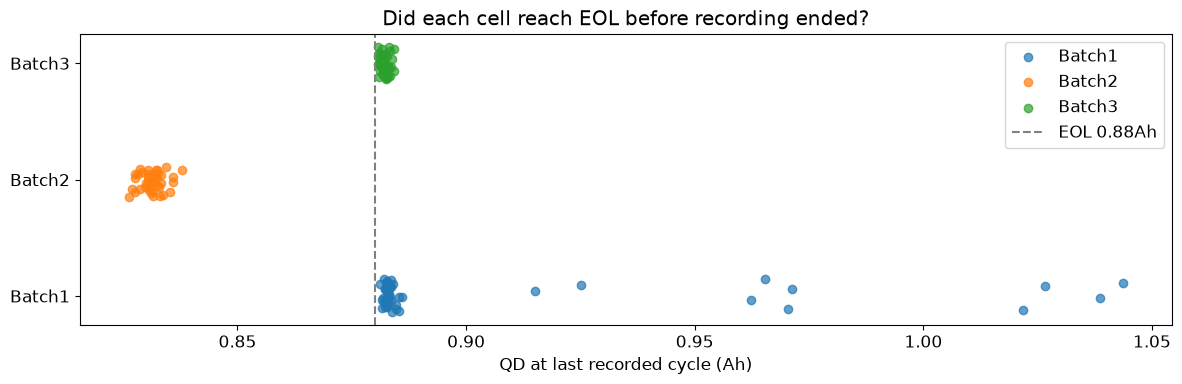

EOL 미도달(제외) 셀 : 10개
  마지막 용량 범위 : 0.915 ~ 1.044
정상 셀 (Batch1·3) 마지막 용량 범위 : 0.881 ~ 0.886
     batch  cell_id  cycle_life  last_QD charging_policy
0   Batch1        0      1190.0    1.026  3.6C(80%)-3.6C
1   Batch1        1      1179.0    1.039  3.6C(80%)-3.6C
2   Batch1        2      1177.0    1.044  3.6C(80%)-3.6C
3   Batch1        3      1226.0    0.971      4C(80%)-4C
4   Batch1        4      1227.0    1.022      4C(80%)-4C
8   Batch1        8       879.0    0.970  5.4C(40%)-3.6C
10  Batch1       10       906.0    0.962    5.4C(50%)-3C
12  Batch1       12       902.0    0.915  5.4C(50%)-3.6C
13  Batch1       13       897.0    0.925  5.4C(50%)-3.6C
22  Batch1       22       891.0    0.965    6C(30%)-3.6C


In [24]:
# Q2-2. 기록 마지막 용량 확인 → 수명 끝(0.88)까지 기록되지 않은 셀 찾기
qd_ok = summary_df[summary_df["QD"].between(0.7, 1.2)]  # 첫 사이클 0값·튀는 값 제외
last_qd = (
    qd_ok.sort_values("cycle")
    .groupby("cell_key")
    .tail(5)  # 셀별 마지막 5사이클
    .groupby("cell_key")["QD"]
    .median()
    .rename("last_QD")
)
valid = valid.drop(columns="last_QD", errors="ignore").join(last_qd, on="cell_key")

# 그림: 배터리 하나 = 점 하나, 가로 위치 = 마지막 용량
rng = np.random.default_rng(42)  # 점 흩뿌리기용 난수 고정 (재현성)
fig, ax = plt.subplots(figsize=(12, 4))
for i, b in enumerate(["Batch1", "Batch2", "Batch3"]):
    d = valid[valid["batch"] == b]
    ax.scatter(d["last_QD"], i + rng.uniform(-0.15, 0.15, len(d)), alpha=0.7, label=b)
ax.axvline(0.88, color="gray", linestyle="--", label="EOL 0.88Ah")
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Batch1", "Batch2", "Batch3"])
ax.set_xlabel("QD at last recorded cycle (Ah)")
ax.set_title("Did each cell reach EOL before recording ended?")
ax.legend()
plt.tight_layout()
plt.show()

not_eol = valid[valid["last_QD"] > 0.9]
normal = valid[valid["last_QD"] <= 0.9]
print(f"EOL 미도달(제외) 셀 : {len(not_eol)}개")
print(
    f"  마지막 용량 범위 : {not_eol['last_QD'].min():.3f} ~ {not_eol['last_QD'].max():.3f}"
)
print(
    f"정상 셀 (Batch1·3) 마지막 용량 범위 : "
    f"{normal[normal['batch'] != 'Batch2']['last_QD'].min():.3f} ~ "
    f"{normal[normal['batch'] != 'Batch2']['last_QD'].max():.3f}"
)
print(
    not_eol[["batch", "cell_id", "cycle_life", "last_QD", "charging_policy"]].round(3)
)

In [26]:
# Q1 재계산 : 정답 없는 셀 + EOL 미도달 셀 제외
clean = normal.copy()
clean.to_pickle("../data/cells_clean.pkl")

g = clean.groupby("batch")["cycle_life"]
q1_clean = pd.DataFrame(
    {
        "배터리 수": g.size(),
        "평균": g.mean().round(1),
        "중앙값": g.median(),
        "표준편차": g.std().round(1),
        "최소": g.min(),
        "최대": g.max(),
        "장수명(>1000)": g.apply(lambda x: (x > 1000).sum()),
        "550 미만": g.apply(lambda x: (x < 550).sum()),
    }
)
q1_clean

,배터리 수,평균,중앙값,표준편차,최소,최대,장수명(>1000),550 미만
batch,,,,,,,,
Batch1,36,788.4,772.5,148.7,534.0,1074.0,5,1
Batch2,39,565.7,472.0,222.2,392.0,1186.0,3,30
Batch3,44,1059.7,1005.5,313.9,541.0,1935.0,23,1


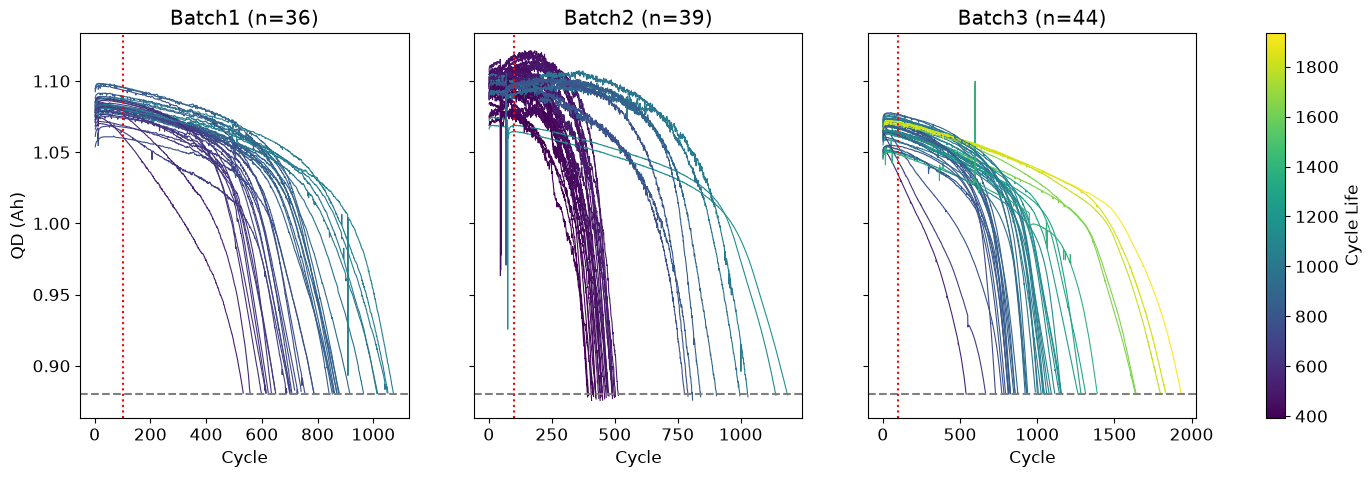

In [27]:
# Q2-3. 배치별 전체 열화 곡선 (정상 셀만) — 색이 밝을수록 수명이 김
clean = pd.read_pickle("../data/cells_clean.pkl")
curves = summary_df.merge(clean[["cell_key", "cycle_life"]], on="cell_key")
curves = curves[
    curves["QD"].between(0.7, 1.2) & (curves["cycle"] <= curves["cycle_life"])
]

norm = plt.Normalize(clean["cycle_life"].min(), clean["cycle_life"].max())
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, b in zip(axes, ["Batch1", "Batch2", "Batch3"]):
    for key, sub in curves[curves["batch"] == b].groupby("cell_key"):
        ax.plot(
            sub["cycle"],
            sub["QD"],
            color=cm.viridis(norm(sub["cycle_life"].iloc[0])),
            lw=0.8,
        )
    ax.axhline(0.88, color="gray", linestyle="--")
    ax.axvline(100, color="red", linestyle=":")
    ax.set_title(f"{b} (n={(clean['batch'] == b).sum()})")
    ax.set_xlabel("Cycle")
axes[0].set_ylabel("QD (Ah)")
fig.colorbar(cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, label="Cycle Life")
plt.show()

In [28]:
# Q2-4. Knee point : 곡선의 처음과 끝을 직선으로 잇고, 곡선이 그 직선에서 가장 멀리 떨어진 지점
def find_knee(cyc, qd):
    qd = (
        pd.Series(qd).rolling(15, center=True, min_periods=1).median().values
    )  # 튀는 값 완화
    x = (cyc - cyc[0]) / (cyc[-1] - cyc[0])  # 가로: 0~1로 맞춤
    y = (qd - qd[-1]) / (qd[0] - qd[-1])  # 세로: 시작=1, 끝=0으로 맞춤
    dist = y - (1 - x)  # 직선(시작→끝)보다 얼마나 위에 있나
    return int(cyc[np.argmax(dist)]), float(dist.max())


rows = []
for key, sub in curves.groupby("cell_key"):
    sub = sub.sort_values("cycle")
    knee, strength = find_knee(sub["cycle"].values.astype(float), sub["QD"].values)
    rows.append(
        {
            "cell_key": key,
            "batch": sub["batch"].iloc[0],
            "cycle_life": sub["cycle_life"].iloc[0],
            "knee": knee,
            "strength": strength,
        }
    )
knee_df = pd.DataFrame(rows)
knee_df["knee_ratio"] = knee_df["knee"] / knee_df["cycle_life"]

knee_summary = (
    knee_df.groupby("batch")
    .agg(
        셀수=("knee", "size"),
        knee_중앙값=("knee", "median"),
        수명대비_위치=("knee_ratio", "median"),
        knee_100번이전=("knee", lambda x: (x <= 100).sum()),
        꺾임정도_중앙값=("strength", "median"),
    )
    .round(2)
)
print(knee_summary)
print(
    "\nknee 위치 vs 수명 상관계수 :",
    round(knee_df["knee"].corr(knee_df["cycle_life"]), 3),
)

        셀수  knee_중앙값  수명대비_위치  knee_100번이전  꺾임정도_중앙값
batch                                               
Batch1  36     550.0     0.71            0      0.50
Batch2  39     328.0     0.69            0      0.52
Batch3  44     764.5     0.76            0      0.50

knee 위치 vs 수명 상관계수 : 0.994


## Q3. ΔQ(V) 곡선

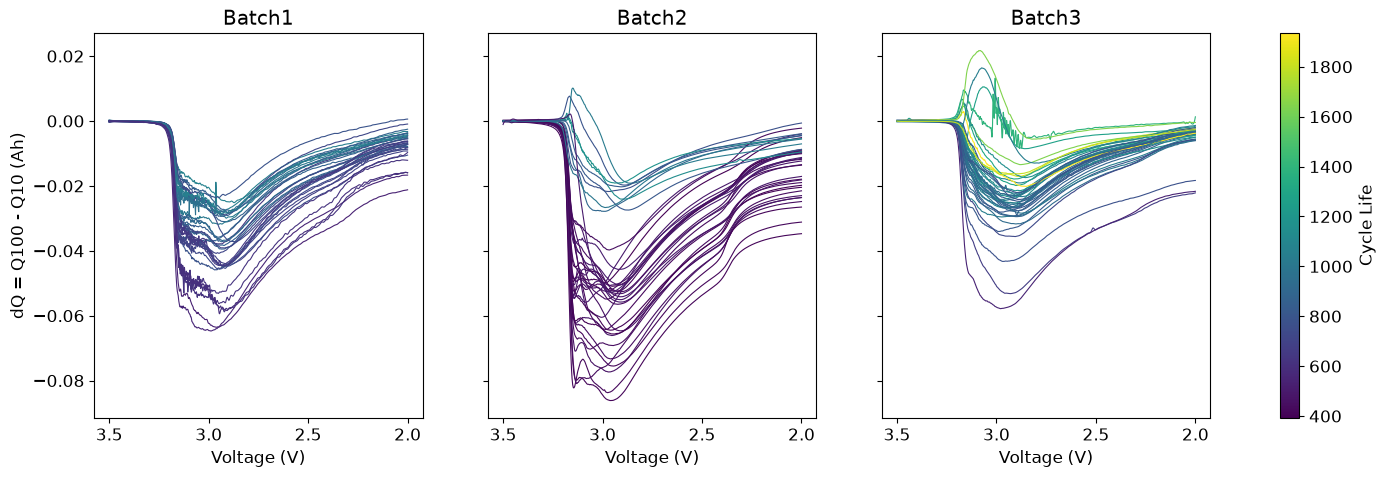

In [29]:
# Q3-1. ΔQ(V) = Q100(V) - Q10(V)
import pickle

with open("../data/qdlin_early.pkl", "rb") as f:
    qdlin_all = pickle.load(f)

V = np.linspace(
    3.5, 2.0, 1000
)  # Qdlin 전압 축 (원본 Vdlin과 동일: 3.5V → 2.0V, 1000점)

dq_curves, rows = {}, []
for _, r in clean.iterrows():
    L = qdlin_all[r["cell_key"]]
    dq = np.asarray(L[99]) - np.asarray(
        L[9]
    )  # index 0 = 1번째 사이클 → index 99 = 100번째, 9 = 10번째
    dq_curves[r["cell_key"]] = dq
    rows.append(
        {
            "cell_key": r["cell_key"],
            "batch": r["batch"],
            "cycle_life": r["cycle_life"],
            "dq_min": dq.min(),
            "dq_mean": dq.mean(),
            "dq_var": dq.var(),
            "dq_logvar": np.log10(dq.var()),
        }
    )
dq_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, b in zip(axes, ["Batch1", "Batch2", "Batch3"]):
    for _, r in dq_df[dq_df["batch"] == b].iterrows():
        ax.plot(
            V, dq_curves[r["cell_key"]], color=cm.viridis(norm(r["cycle_life"])), lw=0.8
        )
    ax.set_title(b)
    ax.set_xlabel("Voltage (V)")
    ax.invert_xaxis()
axes[0].set_ylabel("dQ = Q100 - Q10 (Ah)")
fig.colorbar(cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, label="Cycle Life")
plt.show()

           Batch1  Batch2  Batch3    All
dq_min      0.805   0.819   0.692  0.818
dq_mean     0.768   0.767   0.639  0.786
dq_var     -0.801  -0.733  -0.590 -0.739
dq_logvar  -0.827  -0.902  -0.702 -0.857


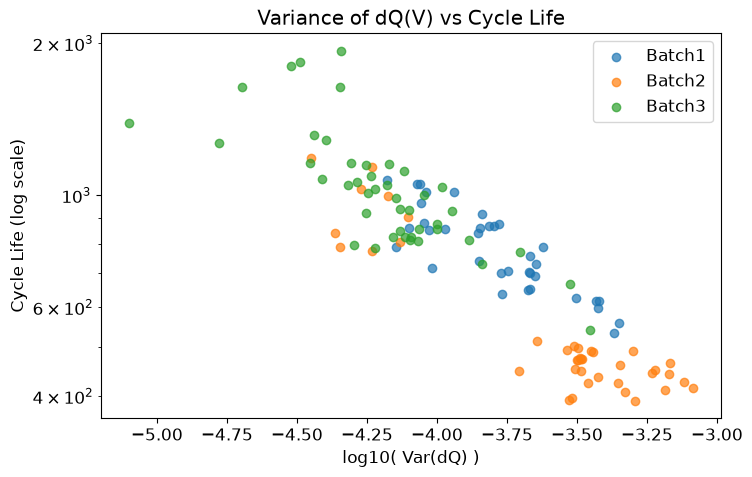

In [30]:
# Q3-2. ΔQ 요약값 vs 수명 : 상관계수 (배치별 + 전체)
feats = ["dq_min", "dq_mean", "dq_var", "dq_logvar"]
corr_tbl = pd.DataFrame(
    {
        b: dq_df[dq_df["batch"] == b][feats].corrwith(
            dq_df[dq_df["batch"] == b]["cycle_life"]
        )
        for b in ["Batch1", "Batch2", "Batch3"]
    }
)
corr_tbl["All"] = dq_df[feats].corrwith(dq_df["cycle_life"])
print(corr_tbl.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
for b in ["Batch1", "Batch2", "Batch3"]:
    d = dq_df[dq_df["batch"] == b]
    ax.scatter(d["dq_logvar"], d["cycle_life"], label=b, alpha=0.7)
ax.set_yscale("log")
ax.set_xlabel("log10( Var(dQ) )")
ax.set_ylabel("Cycle Life (log scale)")
ax.set_title("Variance of dQ(V) vs Cycle Life")
ax.legend()
plt.show()

dq_df.to_pickle("../data/dq_features.pkl")

## Q4. 충전 조건과 수명

방식 종류 수 : {'Batch1': 20, 'Batch2': 9, 'Batch3': 8}
Batch1 ∩ Batch2 : {'4.8C(80%)-4.8C', '6C(60%)-3C'}
Batch1 ∩ Batch3 : {'4.8C(80%)-4.8C'}

         Batch1 Batch2 Batch3    All          
          life   life   life   life dq_logvar
C1      -0.235  0.191 -0.083  0.005     0.013
Q1      -0.175  0.116  0.541  0.167    -0.115
C2      -0.235 -0.116 -0.043 -0.096     0.126
Cavg_80 -0.580  0.334 -0.018 -0.096     0.100


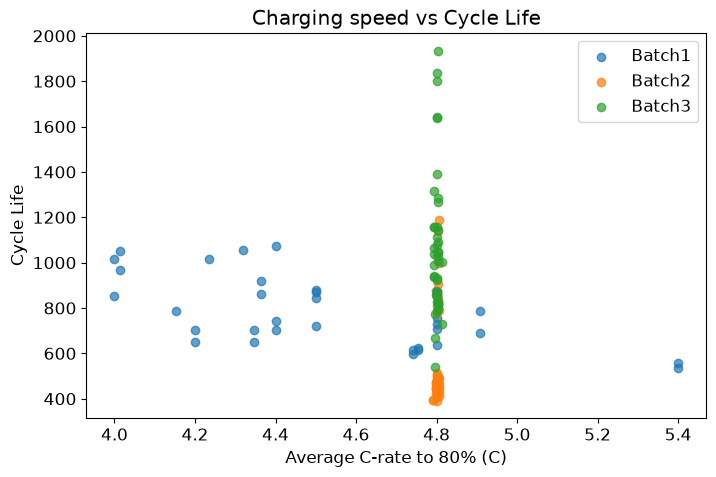

In [31]:
# Q4. 충전 방식(글자) → 숫자 피처로 변환 후 수명과 비교
import re

pat = re.compile(r"^([\d.]+)C\((\d+)%\)-([\d.]+)C")


def parse_policy(p):
    m = pat.match(p)
    C1, Q1, C2 = float(m[1]), float(m[2]), float(m[3])
    t80 = Q1 / 100 / C1 + max(80 - Q1, 0) / 100 / C2  # 0→80% 충전 시간(시간 단위)
    return pd.Series({"C1": C1, "Q1": Q1, "C2": C2, "Cavg_80": 0.8 / t80})


pol = clean[["cell_key", "batch", "cycle_life", "charging_policy"]].copy()
pol = pol.join(pol["charging_policy"].apply(parse_policy))
pol = pol.merge(dq_df[["cell_key", "dq_logvar"]], on="cell_key")  # Q3의 초기 열화 신호

# ① 배치 간 겹치는 충전 방식 수 ('-newstructure' 표기는 떼고 비교)
base = pol["charging_policy"].str.replace("-newstructure", "", regex=False)
sets = {b: set(base[pol["batch"] == b]) for b in ["Batch1", "Batch2", "Batch3"]}
print("방식 종류 수 :", {b: len(s) for b, s in sets.items()})
print("Batch1 ∩ Batch2 :", sets["Batch1"] & sets["Batch2"])
print("Batch1 ∩ Batch3 :", sets["Batch1"] & sets["Batch3"])

# ② 충전 숫자 vs 수명, vs 초기 열화 신호(dq_logvar) 상관계수
feats = ["C1", "Q1", "C2", "Cavg_80"]
out = {}
for b in ["Batch1", "Batch2", "Batch3"]:
    d = pol[pol["batch"] == b]
    out[(b, "life")] = d[feats].corrwith(d["cycle_life"])
out[("All", "life")] = pol[feats].corrwith(pol["cycle_life"])
out[("All", "dq_logvar")] = pol[feats].corrwith(pol["dq_logvar"])
print("\n", pd.DataFrame(out).round(3))

# ③ 그림 : 80%까지 평균 충전 속도 vs 수명
fig, ax = plt.subplots(figsize=(8, 5))
for b in ["Batch1", "Batch2", "Batch3"]:
    d = pol[pol["batch"] == b]
    ax.scatter(d["Cavg_80"], d["cycle_life"], label=b, alpha=0.7)
ax.set_xlabel("Average C-rate to 80% (C)")
ax.set_ylabel("Cycle Life")
ax.set_title("Charging speed vs Cycle Life")
ax.legend()
plt.show()

pol.to_pickle("../data/policy_features.pkl")

## Q5. 상관관계

> 이 칸의 피처 표는 IR이 측정되지 않은 Batch 2 배터리 6개가 빠지는 문제가 있다. 모델링에 쓰는 피처 표는 02_modeling Step 0에서 다시 만든다.

[수명(log)과의 상관]
                Batch1(train)  All(ref)
dq_logvar              -0.844    -0.896
dq_var                 -0.835    -0.827
dq_min                  0.833     0.881
dq_mean                 0.798     0.848
Cavg_80                -0.594    -0.153
chargetime_med          0.575     0.231
QD_slope                0.553    -0.109
QD_diff                 0.519     0.004
C2                     -0.292    -0.179
C1                     -0.238     0.088
Q1                     -0.181     0.124
QD_2                    0.157    -0.619
Tavg_mean              -0.156     0.317
Tmax_mean              -0.150    -0.011
IR_diff                 0.136     0.222
IR_2                    0.116    -0.472


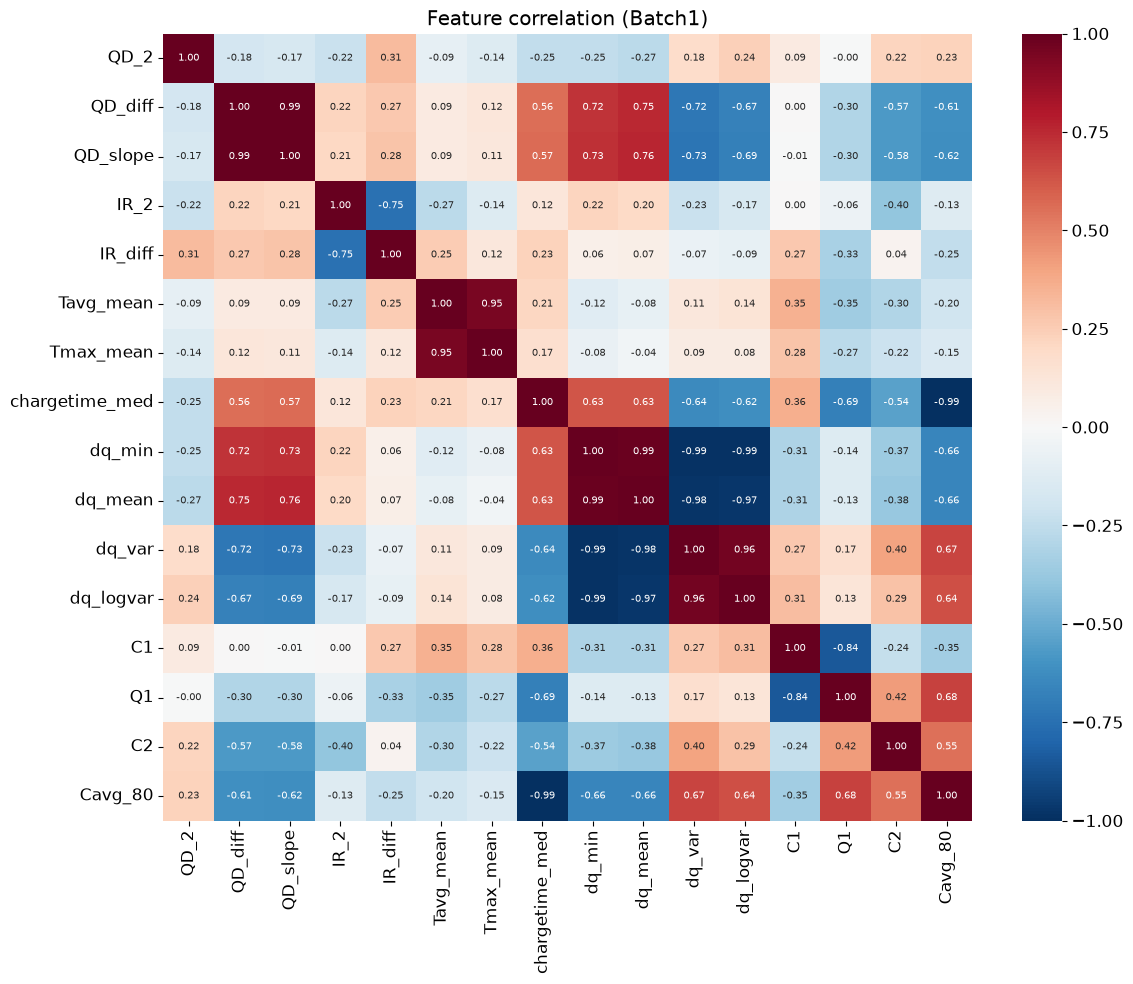


[|r| >= 0.8 인 피처 짝 (Batch1)]
('QD_diff', 'QD_slope', np.float64(0.995))
('chargetime_med', 'Cavg_80', np.float64(-0.994))
('dq_min', 'dq_mean', np.float64(0.992))
('dq_min', 'dq_var', np.float64(-0.99))
('dq_min', 'dq_logvar', np.float64(-0.988))
('dq_mean', 'dq_var', np.float64(-0.984))
('dq_mean', 'dq_logvar', np.float64(-0.971))
('dq_var', 'dq_logvar', np.float64(0.964))
('Tavg_mean', 'Tmax_mean', np.float64(0.953))
('C1', 'Q1', np.float64(-0.845))


In [32]:
# Q5. 초기(2~100 사이클) 피처 모으기 → 수명과 상관 + 피처끼리 겹침(다중공선성)
import seaborn as sns

early = summary_df[
    summary_df["cycle"].between(2, 100)
    & summary_df["QD"].between(0.7, 1.2)
    & (summary_df["IR"] > 0)
]


def early_feats(g):
    g = g.sort_values("cycle")
    return pd.Series(
        {
            "QD_2": g["QD"].iloc[0],  # 2번째 사이클 용량
            "QD_diff": g["QD"].iloc[-1] - g["QD"].iloc[0],  # 100번째 - 2번째
            "QD_slope": np.polyfit(g["cycle"], g["QD"], 1)[0],  # 2~100 용량 감소 기울기
            "IR_2": g["IR"].iloc[0],
            "IR_diff": g["IR"].iloc[-1] - g["IR"].iloc[0],
            "Tavg_mean": g["Tavg"].mean(),
            "Tmax_mean": g["Tmax"].mean(),
            "chargetime_med": g["chargetime"]
            .iloc[:5]
            .median(),  # 초기 5사이클 충전시간
        }
    )


ef = early.groupby("cell_key").apply(early_feats).reset_index()

feat = (
    clean[["cell_key", "batch", "cycle_life"]]
    .merge(ef, on="cell_key")
    .merge(
        dq_df[["cell_key", "dq_min", "dq_mean", "dq_var", "dq_logvar"]], on="cell_key"
    )
    .merge(pol[["cell_key", "C1", "Q1", "C2", "Cavg_80"]], on="cell_key")
)
feat["log_life"] = np.log10(feat["cycle_life"])
feat.to_pickle("../data/features.pkl")

X_cols = [
    "QD_2",
    "QD_diff",
    "QD_slope",
    "IR_2",
    "IR_diff",
    "Tavg_mean",
    "Tmax_mean",
    "chargetime_med",
    "dq_min",
    "dq_mean",
    "dq_var",
    "dq_logvar",
    "C1",
    "Q1",
    "C2",
    "Cavg_80",
]
b1 = feat[feat["batch"] == "Batch1"]

# ① 수명(log)과의 상관 : Batch1 기준 순위
corr_life = pd.DataFrame(
    {
        "Batch1(train)": b1[X_cols].corrwith(b1["log_life"]),
        "All(ref)": feat[X_cols].corrwith(feat["log_life"]),
    }
).sort_values("Batch1(train)", key=abs, ascending=False)
print("[수명(log)과의 상관]")
print(corr_life.round(3))

# ② 피처끼리 상관 (Batch1) : 히트맵 + |r| >= 0.8 짝
cm_b1 = b1[X_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_b1, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, annot_kws={"size": 7}
)
plt.title("Feature correlation (Batch1)")
plt.tight_layout()
plt.show()

pairs = [
    (a, b, round(cm_b1.loc[a, b], 3))
    for i, a in enumerate(X_cols)
    for b in X_cols[i + 1 :]
    if abs(cm_b1.loc[a, b]) >= 0.8
]
print("\n[|r| >= 0.8 인 피처 짝 (Batch1)]")
for p in sorted(pairs, key=lambda x: -abs(x[2])):
    print(p)

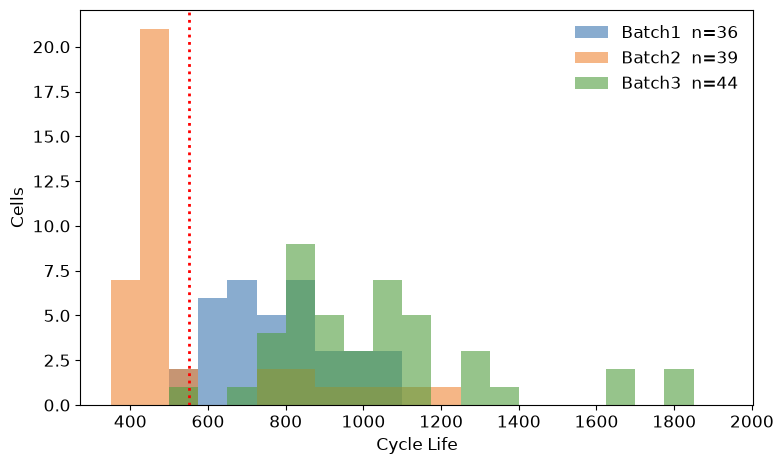

In [33]:
# 보고서용 : 배치별 수명 분포 (정제 후)
col = {"Batch1": "#3B75AF", "Batch2": "#EF8636", "Batch3": "#519E3E"}
fig, ax = plt.subplots(figsize=(8, 4.8))
bins = np.arange(350, 2000, 75)
for b in ["Batch1", "Batch2", "Batch3"]:
    ax.hist(
        clean[clean["batch"] == b]["cycle_life"],
        bins=bins,
        alpha=0.6,
        label=f"{b}  n={(clean['batch'] == b).sum()}",
        color=col[b],
    )
ax.axvline(550, color="red", linestyle=":", lw=2)
ax.set_xlabel("Cycle Life")
ax.set_ylabel("Cells")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

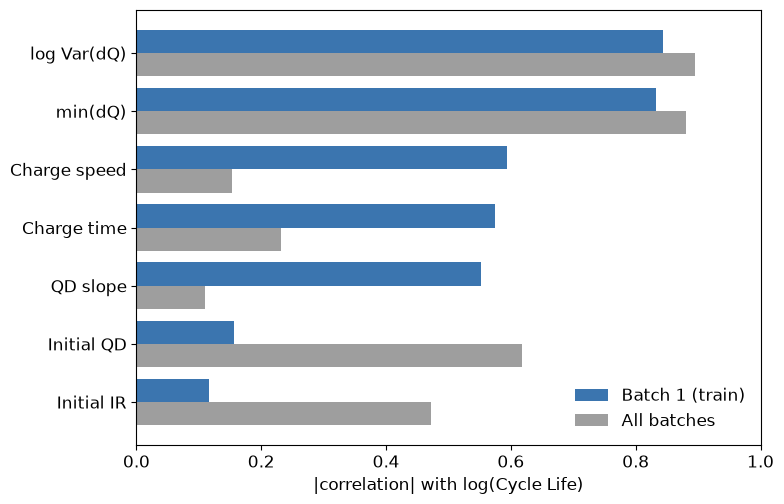

In [34]:
# 보고서용 : 수명(log)과의 상관 크기 비교 — 학습 배치 vs 전체
names = {
    "dq_logvar": "log Var(dQ)",
    "dq_min": "min(dQ)",
    "Cavg_80": "Charge speed",
    "chargetime_med": "Charge time",
    "QD_slope": "QD slope",
    "QD_2": "Initial QD",
    "IR_2": "Initial IR",
}
r_b1 = [abs(b1[k].corr(b1["log_life"])) for k in names]
r_all = [abs(feat[k].corr(feat["log_life"])) for k in names]

fig, ax = plt.subplots(figsize=(8, 5.2))
yy = np.arange(len(names))[::-1]
ax.barh(yy + 0.2, r_b1, 0.4, label="Batch 1 (train)", color=col["Batch1"])
ax.barh(yy - 0.2, r_all, 0.4, label="All batches", color="#9E9E9E")
ax.set_yticks(yy)
ax.set_yticklabels(list(names.values()))
ax.set_xlabel("|correlation| with log(Cycle Life)")
ax.set_xlim(0, 1)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

         셀      평균     중앙값   표준편차    왜도  >1000(%)  <500(%)  log 왜도
batch                                                             
Batch1  36   788.4   772.5  148.7  0.30      13.9      0.0   -0.01
Batch2  39   565.7   472.0  222.2  1.64       7.7     71.8    1.36
Batch3  44  1059.7  1005.5  313.9  1.26      52.3      0.0    0.52


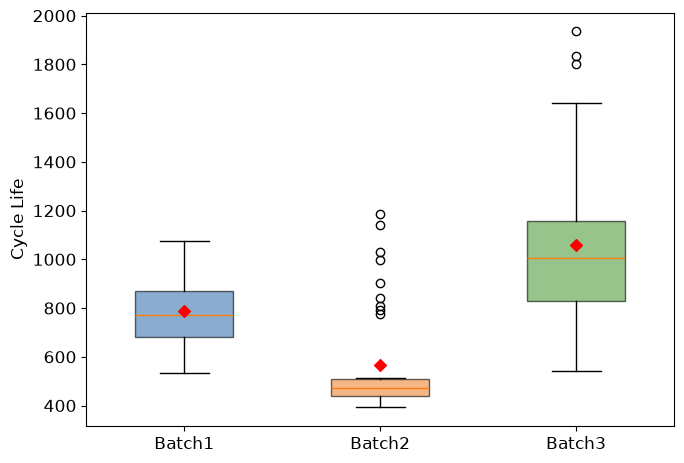

In [35]:
# 보고서용 : 배치별 수명 통계량 + 상자그림
col = {"Batch1": "#3B75AF", "Batch2": "#EF8636", "Batch3": "#519E3E"}
g = clean.groupby("batch")["cycle_life"]
stats = pd.DataFrame(
    {
        "셀": g.size(),
        "평균": g.mean().round(1),
        "중앙값": g.median(),
        "표준편차": g.std().round(1),
        "왜도": g.skew().round(2),
        ">1000(%)": g.apply(lambda x: (x > 1000).mean() * 100).round(1),
        "<500(%)": g.apply(lambda x: (x < 500).mean() * 100).round(1),
        "log 왜도": clean.assign(l=np.log10(clean["cycle_life"]))
        .groupby("batch")["l"]
        .skew()
        .round(2),
    }
)
print(stats)

fig, ax = plt.subplots(figsize=(7, 4.8))
data = [
    clean[clean["batch"] == b]["cycle_life"] for b in ["Batch1", "Batch2", "Batch3"]
]
bp = ax.boxplot(data, patch_artist=True, widths=0.5)
for p, b in zip(bp["boxes"], ["Batch1", "Batch2", "Batch3"]):
    p.set_facecolor(col[b])
    p.set_alpha(0.6)
for i, d in enumerate(data, 1):
    ax.scatter(i, d.mean(), marker="D", color="red", zorder=3)  # 빨간 점 = 평균
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Batch1", "Batch2", "Batch3"])
ax.set_ylabel("Cycle Life")
plt.tight_layout()
plt.show()

                   life  n     c
charging_policy                 
5.4C(80%)-5.4C    546.5  2  5.40
8C(35%)-3.6C      607.5  2  4.74
7C(40%)-3.6C      621.0  2  4.75
7C(40%)-3C        676.0  2  4.20
8C(25%)-3.6C      676.5  2  4.35
7C(30%)-3.6C      722.5  2  4.40
5.4C(70%)-3C      739.5  2  4.91
6C(60%)-3C        744.0  2  4.80
4.8C(80%)-4.8C    753.0  2  4.80
5.4C(50%)-3C      788.0  1  4.15
6C(50%)-3.6C      792.5  2  4.80
5.4C(60%)-3C      799.5  2  4.50
6C(40%)-3.6C      856.0  2  4.50
5.4C(60%)-3.6C    859.5  2  4.80
6C(50%)-3C        888.5  2  4.36
6C(40%)-3C        935.5  2  4.00
8C(15%)-3.6C     1008.5  2  4.01
6C(30%)-3.6C     1014.0  1  4.24
5.4C(40%)-3.6C   1054.0  1  4.32
4.4C(80%)-4.4C   1074.0  1  4.40


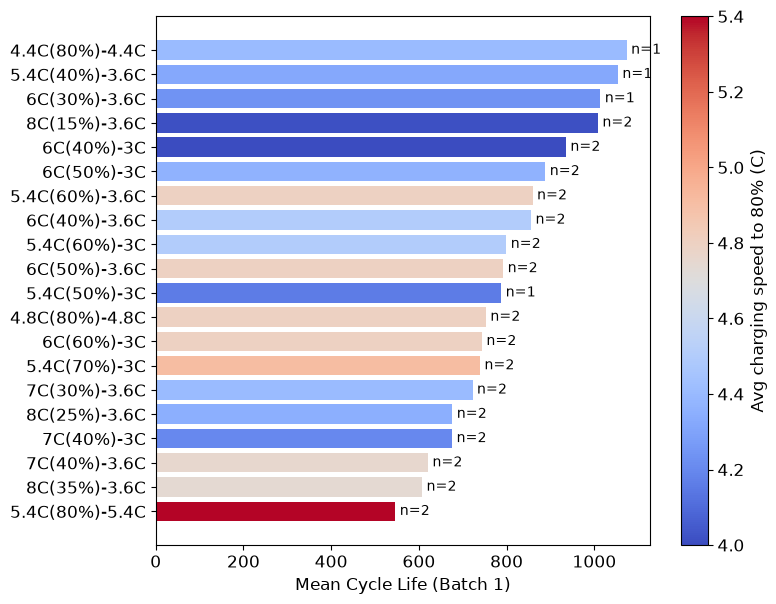

In [36]:
# 보고서용 : Batch 1 충전 방식별 평균 수명 (색 = 80%까지 평균 충전 속도)
b1p = pol[pol["batch"] == "Batch1"]
gp = (
    b1p.groupby("charging_policy")
    .agg(life=("cycle_life", "mean"), n=("cycle_life", "size"), c=("Cavg_80", "first"))
    .sort_values("life")
)
print(gp.round(2))

fig, ax = plt.subplots(figsize=(8, 6.2))
nrm = plt.Normalize(gp["c"].min(), gp["c"].max())
ax.barh(gp.index, gp["life"], color=cm.coolwarm(nrm(gp["c"])))
for y, (l, n) in enumerate(zip(gp["life"], gp["n"])):
    ax.text(l + 10, y, f"n={n}", va="center", fontsize=10)
ax.set_xlabel("Mean Cycle Life (Batch 1)")
fig.colorbar(
    cm.ScalarMappable(norm=nrm, cmap="coolwarm"),
    ax=ax,
    label="Avg charging speed to 80% (C)",
)
plt.tight_layout()
plt.show()